# IM Lup with the interpolated resolved source

This notebook fits the IM Lup coronagraphic exposures (F160W, three roll angles) with a point source plus a resolved disk, exactly as `batch/imlup-turboklip.py` does, but selects `InterpolatedResolvedSource` instead of the exact `CursedResolvedSource`.
The exact source propagates one PSF per distribution pixel (60x60 = 3600 propagations per model call). The interpolated source propagates only K PSFs at "anchor" positions (a centre anchor plus rings in a polar layout, dense near the occulter where the PSF varies fast), splats the distribution onto each anchor with partition-of-unity interpolation weights, and sums the FFT convolutions of each anchor PSF with its weighted image.
Edit the **Settings** cell to change the anchor layout, resolved grid, regulariser and optimiser schedule.

In [13]:
import sys
sys.path.insert(0, '..')

In [14]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import interpax as ipx


## Settings
Everything you are likely to want to change lives in this cell.

In [15]:
# ---- Settings: play with these ----

# Interpolated source: anchor layout (polar: one centre anchor + a ring per radius)
resolved_source = "interp"          # "interp" or "exact" (exact = original CursedResolvedSource, slow)
anchor_radii = (0.1, 0.2, 0.3, 0.4, 0.5, 0.65, 0.85, 1.1, 1.5, 2.2)   # arcsec, dense near the occulter
anchor_radii = (0.1, 0.3, 0.5,  0.85,  1.5, 2.2)   # arcsec, dense near the occulter

n_angular = 4                       # anchors per ring -> K = n_angular * n_rings (+1 centre if exact_radius = 0)
exact_radius = 0.6                  # arcsec; pixels inside are propagated exactly. 0.6 gives ~0.2-0.6% error on smooth
                                    # sources at ~2.9 s/forward vs ~60 s exact; 0.8 is more accurate at ~4 s; 0 = pure interpolation
include_centre = True               # centre anchor (only used when exact_radius = 0)
batch_size = 4                      # lax.map batch size for the anchor propagations (memory vs speed)
grad_optics = False                 # True: gradients also flow through the anchor PSFs (more memory/time)

# Resolved distribution
resolved_wid = 15                   # resolved grid is resolved_wid x resolved_wid pixels
pitch_arcsec = 0.0432 * 8           # resolved pixel pitch
regulariser = np.array([0.05, 0.5])

# Optical model / data
wid = 80
oversample = 4
nwavels = 20
npoly = 8
n_modes = 45
n_zernikes = 50

# Optimisation
epochs = 1000
g = 5e-2                            # base learning rate
resolved_lr = 3e-2                  # adam learning rate for the resolved distribution
resolved_delay = 150                # epoch at which the resolved distribution starts to update
precond_kwargs = dict(n_probes=32)

# Compare interpolated vs exact on a single model evaluation (see the comparison cell below)
compare_exact = False               # WARNING: exact is slow at 60x60 (3600 propagations); try a small compare_wid first
compare_wid = 16                    # grid size used only for the comparison

# Paths
ddir = '../data/NICMOS-LAPL-DD2/LAPL_DATA_DD2/comtemp_flats-DD2/'
flatdir = '../data/NICMOS-LAPL-DD2/LAPL_HOLEFLATS_DD2/'

## Optics, data and model

In [16]:
optics = NICMOSCoronagraph(512, wid, oversample, n_modes=n_modes, n_zernikes=n_zernikes, turboklip="../data/turboklip.npz", wl_batch=5, remat=True)

detector = NICMOSDetector(oversample, wid)

vects = np.load("../data/iterative_spectrum_basis_F160W.npy")[:,:npoly]
assert vects.shape == (nwavels, npoly)
spectrum_basis = vects/np.sqrt(np.mean(vects**2, axis=0))

resolved_kwargs = dict(anchor_radii=anchor_radii, n_angular=n_angular, exact_radius=exact_radius,
                       include_centre=include_centre, grad_optics=grad_optics, batch_size=batch_size)

def make_fit():
    fit = PointResolvedFit(spectrum_basis, "F160W", wid=resolved_wid, regulariser=regulariser,
                           resolved_source=resolved_source,
                           resolved_kwargs=resolved_kwargs if resolved_source == "interp" else None)
    # PointResolvedFit hard-codes the pitch, so rebuild the resolved source with pitch_arcsec
    r = fit.source.resolved
    new = type(r)(distribution=r.distribution, pitch=dlu.arcsec2rad(pitch_arcsec), roll=r.roll,
                  wavelengths=r.wavelengths, spectrum=r.spectrum,
                  **(resolved_kwargs if resolved_source == "interp" else {}))
    return fit.set("source.resolved", new)

exposures_single = [
    exposure_from_file(ddir + 'n8zu11epq_m_clc_calf.fits', make_fit(), crop=wid, flatcorr=flatdir),
    # exposure_from_file(ddir + 'n8zu11eqq_m_clc_calf.fits', make_fit(), crop=wid, flatcorr=flatdir),
    # exposure_from_file(ddir + 'n8zu12exq_m_clc_calf.fits', make_fit(), crop=wid, flatcorr=flatdir),
]

223.9605 5.4
Version 4.1.1
-121.63


ADCZERO                    0.0 / analog-digital conversion zero level (DN)       [astropy.io.fits.card]


In [17]:
params = {
    "spectrum": {},
    "primary_klip": {},
    "primary_low": {},
    "primary_tilt": {},
    "cold_mask_tilt": {},
    "bias": {},
    "resolved": {},
}


for idx, exp in enumerate(exposures_single):
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set((np.nansum(exp.data)/nwavels)*60)

    params["primary_tilt"][exp.fit.get_key(exp, "primary_tilt")] = np.array([-0.75, 0.05])*0.075
    params["cold_mask_tilt"][exp.fit.get_key(exp, "cold_mask_tilt")] = np.array([
        np.array(exp.hdr["TARSIAFX"],dtype=float) - (256-181), 
        np.array(exp.hdr["TARSIAFY"],dtype=float) - (256-44)
    ])*0.075

    params["primary_klip"][exp.fit.get_key(exp, "primary_klip")] = np.zeros(7)
    params["primary_low"][exp.fit.get_key(exp, "primary_low")] = np.zeros(n_zernikes)

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    params["resolved"][exp.fit.get_key(exp, "resolved")] = np.zeros((resolved_wid, resolved_wid))


params = params | np.load("../data/optical_params.npy", allow_pickle=True)[()]


model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))

params = ModelParams(params)

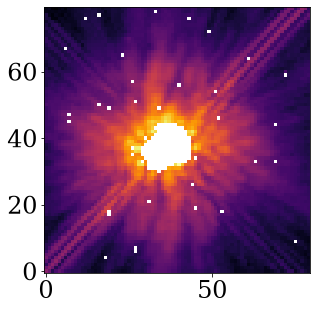

In [18]:
plt.imshow(exposures_single[0].data**0.125)

## Anchor layout and interpolation weights
Left: anchor positions (red) over the resolved field of view, with the approximate occulter (dashed white) and the exact-core radius (dotted yellow; pixels inside it are propagated exactly, with no anchors).
Right: interpolation weights of one anchor (choose `show_anchor`); weights over all anchors sum to one at every pixel.
Weights are taken from the source itself (polar bilinear in r, theta); they are zero inside the exact core. Requires `resolved_source = "interp"`.

K anchors: 16 | exact core radius [arcsec]: 0.6
max |sum(w)-1| over pixels: 0.0


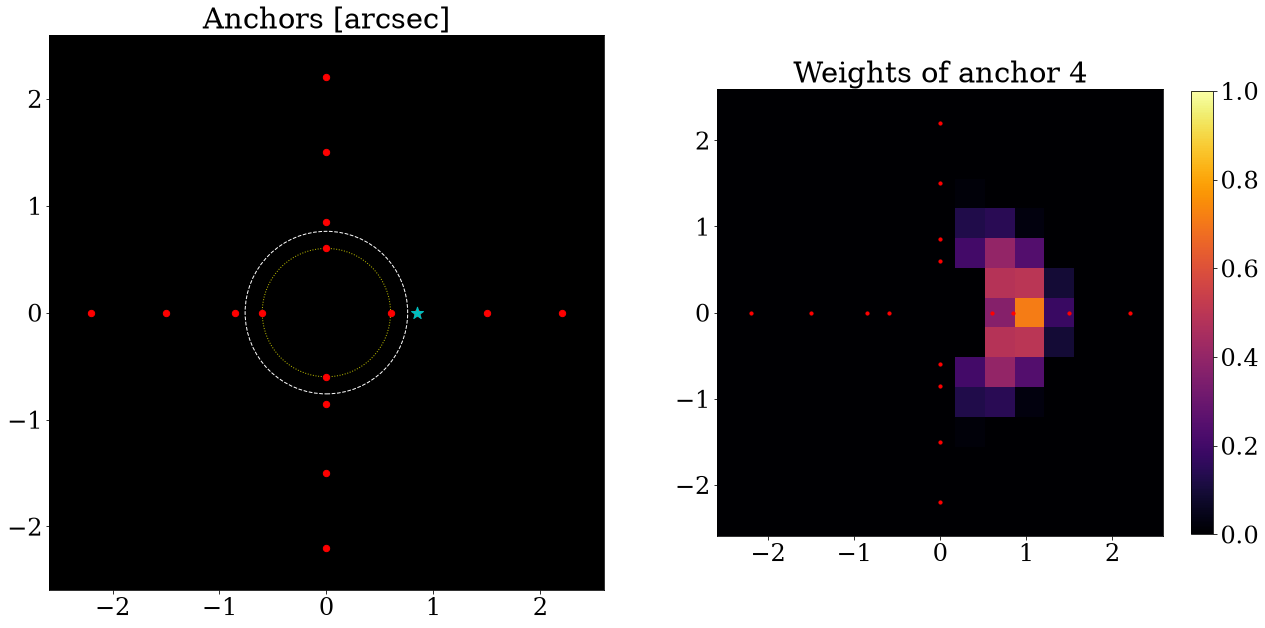

In [19]:
show_anchor = n_angular             # index into the anchor list (K anchors, ring by ring)

half = resolved_wid*pitch_arcsec/2
xs = (numpy.arange(resolved_wid) - (resolved_wid - 1)/2)*pitch_arcsec
X, Y = numpy.meshgrid(xs, xs)

src = exposures_single[0].fit.source.resolved
anchors = numpy.array(dlu.rad2arcsec(src.anchors()))                 # (K, 2) arcsec
if resolved_source == "interp":
    # the source's own weights, evaluated at roll = 0 for display
    W = numpy.array(src.weights_matrix(dlu.arcsec2rad(np.hypot(X, Y).flatten()),
                                       np.arctan2(Y, X).flatten()))   # (K, npix)
    W = W.T.reshape(resolved_wid, resolved_wid, -1)
    print("K anchors:", len(anchors), "| exact core radius [arcsec]:", exact_radius)
    print("max |sum(w)-1| over pixels:", abs(W.sum(-1) - 1).max())

if resolved_source == "interp":
    fig, axs = plt.subplots(1, 2, figsize=(22, 10))
    ax = axs[0]
    ax.add_patch(plt.Circle((0, 0), 0.76, fill=False, ls="--", color="w"))
    ax.add_patch(plt.Circle((0, 0), exact_radius, fill=False, ls=":", color="y"))
    ax.imshow(numpy.zeros((2, 2)), extent=(-half, half, -half, half), cmap="gray")
    ax.scatter(*anchors.T, c="r", s=40)
    ax.scatter(*anchors[show_anchor], c="c", s=160, marker="*")
    ax.set(xlim=(-half, half), ylim=(-half, half), title="Anchors [arcsec]")
    im = axs[1].imshow(W[..., show_anchor], extent=(-half, half, -half, half), vmin=0, vmax=1)
    axs[1].scatter(*anchors.T, c="r", s=10)
    axs[1].set(title=f"Weights of anchor {show_anchor}")
    plt.colorbar(im, ax=axs[1], shrink=0.8)
    plt.show()

## Compare against the exact source (optional)
Set `compare_exact = True` in the settings to evaluate both sources once on the same distribution and compare images.
Exact propagates `compare_wid`^2 PSFs, so keep `compare_wid` small (e.g. 16-20); at 60x60 it takes ~50 s or more per call.

In [20]:
if compare_exact:
    exp = exposures_single[0]
    optics_exp = exp.fit.update_optics(model_single, exp)
    base = exp.fit.update_source(model_single, exp).resolved

    # Test distribution: a smooth ring, on a compare_wid grid with the same pitch
    xc = (numpy.arange(compare_wid) - (compare_wid - 1)/2)/compare_wid
    r = numpy.hypot(*numpy.meshgrid(xc, xc))
    dist = np.array(numpy.exp(-0.5*((r - 0.3)/0.1)**2))

    kw = dict(wavelengths=base.wavelengths, spectrum=base.spectrum, distribution=dist,
              pitch=base.pitch, roll=base.roll)
    exact = CursedResolvedSource(**kw)
    interp = InterpolatedResolvedSource(**kw, **resolved_kwargs)

    import time
    t0 = time.time(); im_exact = exact.model(optics_exp).block_until_ready(); t1 = time.time()
    im_interp = interp.model(optics_exp).block_until_ready(); t2 = time.time()
    print(f"exact {t1-t0:.1f}s (incl. compile), interp {t2-t1:.1f}s (incl. compile)")

    err = im_interp - im_exact
    print("max |err| / max exact:", float(abs(err).max()/abs(im_exact).max()))
    fig, axs = plt.subplots(1, 3, figsize=(30, 10))
    axs[0].imshow(im_exact**0.25);  axs[0].set_title("exact")
    axs[1].imshow(im_interp**0.25); axs[1].set_title("interp")
    c = axs[2].imshow(err/abs(im_exact).max(), cmap="RdBu_r", vmin=-0.01, vmax=0.01)
    axs[2].set_title("(interp - exact) / max"); plt.colorbar(c, ax=axs[2], shrink=0.8)
    plt.show()

(45, 45) 45
(45, 45) 45
(45, 45) 45
(45, 45) 45
34.49705127495401


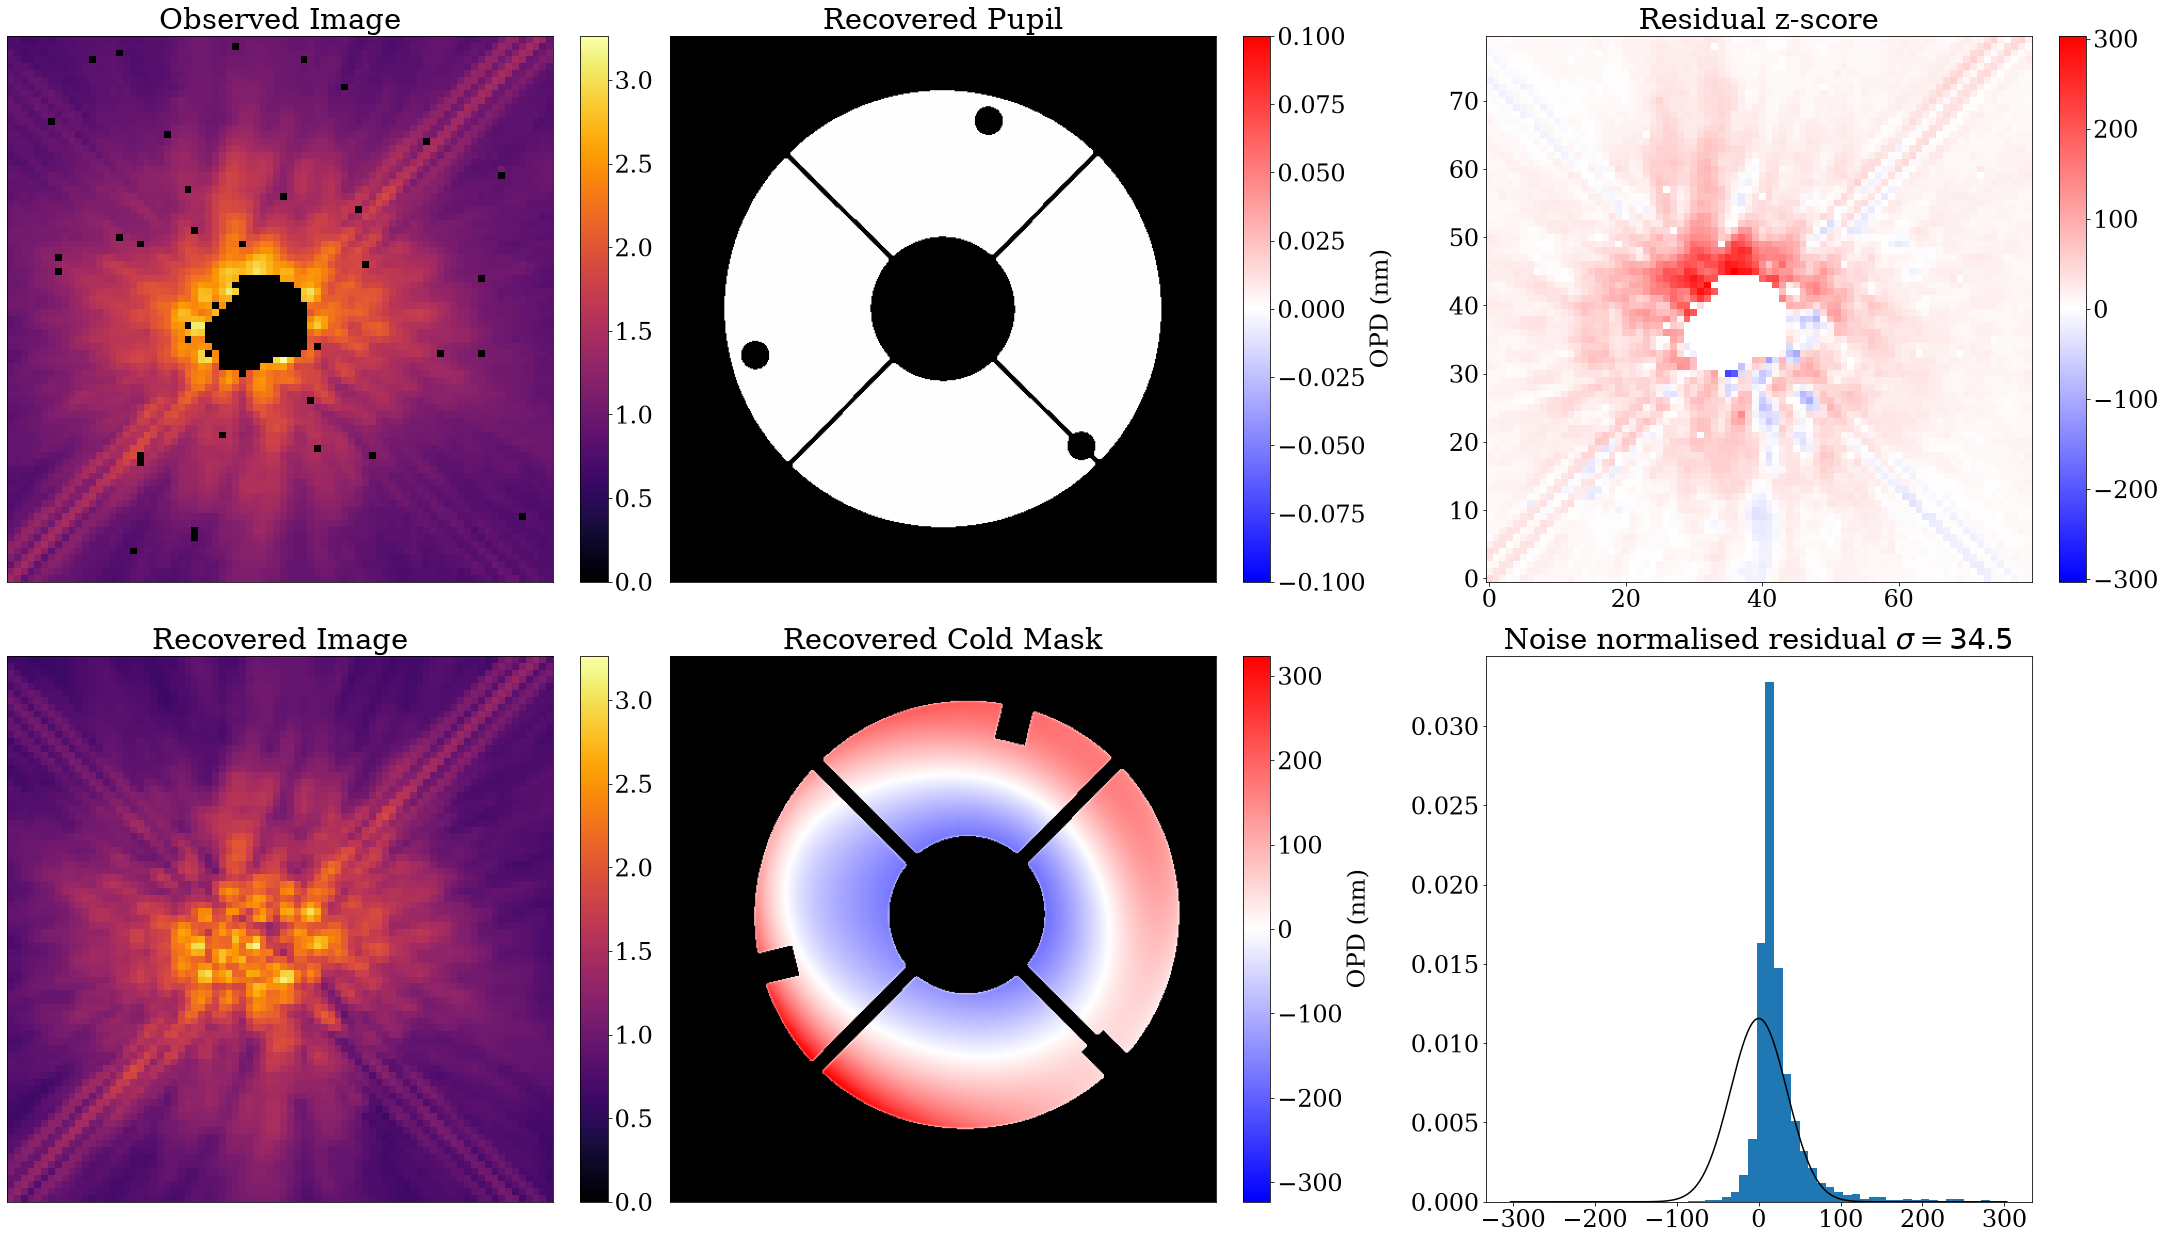

In [21]:
plot_comparison(model_single, params, exposures_single)

## Optimisers

In [22]:
things_start = {
    "spectrum": sgd(g*3, 30.),
    "primary_tilt": sgd(g*1, 15.),
    "cold_mask_tilt": sgd(g*0.1, 0),

    "bias": sgd(g*3, 40),
    "cold_mask_shift": sgd(g*0.1, 50),

    "primary_low": sgd(g*0.05, 70),
    "cold_mask_opd": sgd(g*1., 70),
    "primary_klip": sgd(g*2, 100),

    "resolved": adam(resolved_lr, resolved_delay),
}

In [23]:
orig_params = params.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

## Fit

In [ ]:
losses, params_history = optimise_new_resolved(
    opt_params, model_single, exposures_single, things_start, epochs,
    precond_method="gn_probe", precond_kwargs=precond_kwargs, precond_resolved=True)

(45, 45) 45
(45, 45) 45
(45, 45) 45
(45, 45) 45
(45, 45) 45
(45, 45) 45
(45, 45) 45
(45, 45) 45
(45, 45) 45
(45, 45) 45
(45, 45) 45
(45, 45) 45


  0%|          | 0/1000 [00:00<?, ?it/s]

(45, 45) 45
(45, 45) 45
(45, 45) 45
(45, 45) 45


In [ ]:
plt.plot(losses)

In [ ]:
plot_params(params_history, list(things_start.keys()), xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, quadrature=False, percentile=99, klip=True)

In [ ]:
key = exposures_single[0].fit.get_key(exposures_single[0], "resolved")
fig, axs = plt.subplots(1, 2, figsize=(22, 10))
c0 = axs[0].imshow(10**(params_history[-1]["resolved"][key]));  axs[0].set_title("Resolved distribution")
c1 = axs[1].imshow(params_history[-1]["resolved"][key]);       axs[1].set_title("log10 distribution")
plt.colorbar(c0, ax=axs[0], shrink=0.8); plt.colorbar(c1, ax=axs[1], shrink=0.8)
plt.show()